# Optional Project - Transformer Scaling Laws on SVGs

Vincent Hepola - vh2308


# 0. Imports


In [112]:
from IPython.display import SVG, display
from datasets import load_dataset
import torch


device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)

from lxml import etree
import cairosvg

import numpy as np
from tqdm.auto import tqdm

import re

# 1. Data Collecting and Preprocessing


## 1.1 Dataset


In [61]:
dataset = load_dataset("starvector/svg-icons-simple")

In [62]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 80434
    })
    test: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 2682
    })
    val: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 6254
    })
})

In [63]:
train_data = dataset['train']

In [64]:
svgs = np.array(train_data["Svg"])

In [65]:
svgs

array(['<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432 C10.977089881896973 7.366771697998047 14.58566665649414 7.627137660980225 14.384374618530273 9.36875057220459 C14.17175006866455 11.208415031433105 10.620377540588379 11.302374839782715 9.46875 11.240625381469727 C8.640908241271973 11.196237564086914 4.810017108917236 10.606165885925293 5.704833984375 8.710693359375 C6.279782772064209 7.492790699005127 8.955889701843262 7.426052093505859 10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432"></path>\n<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 9.215624809265137 L10.059374809265137 9.215624809265137 C10.72203254699707 9.315858840942383 14.316993713378906 10.194662094116211 11.5437507629394

### View Sample


In [66]:
sample_1 = svgs[0]


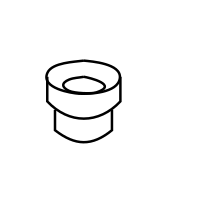

In [67]:
display(SVG(sample_1))

## 1.2 Normalizing/Cleaning

- Strip comments, metadata, and unnecessary whitespace
- Normalize coordinate precision (e.g., round to 1 decimal place) to reduce vocabulary
- Optionally canonicalize attribute ordering
- Remove SVGs that are too short (< 50 characters) or too long (above your chosen token threshold)
- Validate that all SVGs in the cleaned set parse as valid XML
- Ensure all SVGs render without errors (use lxml for XML parsing, optionally CairoSVG for render validation)


In [68]:
def clean_svg(svg_text):
    # Remove XML comments
    svg_text = re.sub(r'', '', svg_text, flags=re.DOTALL)
    
    # Normalize coordinates to 1 decimal place
    # \d+\.\d+ captures numbers like 0.0, 1.323, 123.4 
    # Does not capture numbers like .0, 1, or 1.
    svg_text = re.sub(r'\d+\.\d+', lambda m: str(round(float(m.group(0)), 1)), svg_text)
    
    # Strip extra whitespace, leaving single-spaced text with no leading/trailing space
    svg_text = re.sub(r'\s+', ' ', svg_text).strip()
    
    return svg_text

In [69]:
print(sample_1)
svg_string = clean_svg(sample_1)

print(
)
print(svg_string)

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432 C10.977089881896973 7.366771697998047 14.58566665649414 7.627137660980225 14.384374618530273 9.36875057220459 C14.17175006866455 11.208415031433105 10.620377540588379 11.302374839782715 9.46875 11.240625381469727 C8.640908241271973 11.196237564086914 4.810017108917236 10.606165885925293 5.704833984375 8.710693359375 C6.279782772064209 7.492790699005127 8.955889701843262 7.426052093505859 10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 9.215624809265137 L10.059374809265137 9.215624809265137 C10.72203254699707 9.315858840942383 14.316993713378906 10.194662094116211 11.543750762939453 11.096

In [70]:
TOKEN_THRESHOLD = 1024

# count = 0

# # print(len(dataset["train"]))

# for svg in tqdm(svgs):
#     svg_string  = clean_svg(svg)
#     # print(len(svg_string))
#     if len(svg_string) <= TOKEN_THRESHOLD:
#         count += 1

In [71]:
# print(count/len(dataset["train"]))

### Clean and verify all svgs in training set


In [72]:
def dict_map(d):
    cleaned_string = clean_svg(d["Svg"])
    return {"Filename": d["Filename"], "Svg": cleaned_string}

cleaned_train = train_data.map(dict_map)

In [73]:
print(f"cleaned_train.num_rows: {cleaned_train.num_rows}")

cleaned_train.num_rows: 80434


In [74]:
def is_valid(d):
    svg_string = d["Svg"]
    
    if len(svg_string) <= 50 or len(svg_string) > TOKEN_THRESHOLD:
        return False
    
    try:
        etree.fromstring(svg_string.encode('utf-8'))
    except etree.XMLSyntaxError:
        return False
    
    return True

def valid_render(d):
    svg_string = d["Svg"]
    
    try:
        cairosvg.svg2png(bytestring=svg_string.encode('utf-8'))
    except:
        return False
    
    return True
    

filtered_train = cleaned_train.filter(is_valid)
filtered_train = filtered_train.filter(valid_render)

In [75]:
print(f"filtered_train.num_rows: {filtered_train.num_rows}")

filtered_train.num_rows: 17706


In [76]:
filtered_train

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 17706
})

## 1.3 Tokenize

Train a BPE tokenizer on your SVG corpus using sentencepiece or the HuggingFace
tokenizers library. Vocabulary sizes in the range 1K–8K are reasonable. Document the vocabulary
size and justify your choice in the report.


In [77]:
VOCAB_SIZE = 1000

In [78]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [79]:
tokenizer = Tokenizer(models.BPE())

tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

trainer = trainers.BpeTrainer(
    special_tokens=["<|endoftext|>", "<|pad|>"],
    vocab_size=VOCAB_SIZE
)

In [80]:
tokenizer

Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[], normalizer=None, pre_tokenizer=Whitespace(), post_processor=None, decoder=None, model=BPE(dropout=None, unk_token=None, continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={}, merges=[]))

In [81]:
tokenizer.train_from_iterator(filtered_train["Svg"],trainer)

In [82]:
sample_2 = filtered_train["Svg"][0]
sample_2

'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M10.1 7.3 L10.1 7.3 C11.0 7.4 14.6 7.6 14.4 9.4 C14.2 11.2 10.6 11.3 9.5 11.2 C8.6 11.2 4.8 10.6 5.7 8.7 C6.3 7.5 9.0 7.4 10.1 7.3 L10.1 7.3"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M10.1 9.2 L10.1 9.2 C10.7 9.3 14.3 10.2 11.5 11.1 C11.0 11.3 9.0 11.2 8.3 10.9 C7.4 10.5 7.3 10.0 8.3 9.6 C8.8 9.3 9.5 9.3 10.1 9.2 L10.1 9.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M14.4 9.2 L14.4 12.2 C13.1 13.5 11.6 14.2 10.1 14.2 C8.5 14.2 7.0 13.5 5.7 12.2 L5.7 9.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M13.4 13.2 L13.4 15.6 C12.2 16.6 11.1 17.1 10.0 17.1 C8.9 17.1 7.8 16.6 6.6 15.6 L6.6 13.2"></path></svg>'

In [83]:
encoded_sample_2 = tokenizer.encode(sample_2)

print(encoded_sample_2)


# First 10 tokens on encoding
for id, token in zip(encoded_sample_2.ids[:10], encoded_sample_2.tokens[:10]):
    print(f"{id} -> {token}")

Encoding(num_tokens=460, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
17 -> <
91 -> svg
128 -> xmlns
46 -> ="
122 -> http
106 -> ://
123 -> www
4 -> .
118 -> w3
4 -> .


In [84]:
tokenizer.decode(encoded_sample_2.ids)

'< svg xmlns =" http :// www . w3 . org / 2000 / svg " viewBox =" 0 . 0 0 . 0 24 . 0 24 . 0 " height =" 200px " width =" 200px ">< path fill =" none " stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M10 . 1 7 . 3 L10 . 1 7 . 3 C11 . 0 7 . 4 14 . 6 7 . 6 14 . 4 9 . 4 C14 . 2 11 . 2 10 . 6 11 . 3 9 . 5 11 . 2 C8 . 6 11 . 2 4 . 8 10 . 6 5 . 7 8 . 7 C6 . 3 7 . 5 9 . 0 7 . 4 10 . 1 7 . 3 L10 . 1 7 . 3 "></ path > < path fill =" none " stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M10 . 1 9 . 2 L10 . 1 9 . 2 C10 . 7 9 . 3 14 . 3 10 . 2 11 . 5 11 . 1 C11 . 0 11 . 3 9 . 0 11 . 2 8 . 3 10 . 9 C7 . 4 10 . 5 7 . 3 10 . 0 8 . 3 9 . 6 C8 . 8 9 . 3 9 . 5 9 . 3 10 . 1 9 . 2 L10 . 1 9 . 2 "></ path > < path fill =" none " stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M14 . 4 9 . 2 L14 . 4 12 . 2 C13 . 1 13 . 5 11 . 6 14 . 2 10 . 1 14 . 2 C8 . 5 14 . 2 7 . 0 13 . 5 5 . 7 12 . 2

In [85]:
def tokenize_svg(d):
    
    svg_string = d["Svg"]
    
    ids = tokenizer.encode(svg_string).ids
    
    eot_token = tokenizer.token_to_id("<|endoftext|>")
    
    ids.append(eot_token)
    
    return {"Filename": d["Filename"], "Svg": d["Svg"], "input_ids": ids}

In [86]:
tokenized_train = filtered_train.map(tokenize_svg)

In [101]:
tokenized_train['input_ids']

Column([[17, 91, 128, 46, 122, 106, 123, 4, 118, 4, 126, 5, 121, 5, 91, 2, 127, 46, 6, 4, 6, 6, 4, 6, 94, 4, 6, 94, 4, 6, 2, 125, 46, 98, 2, 68, 46, 98, 65, 57, 58, 46, 86, 2, 54, 46, 84, 2, 54, 3, 68, 80, 9, 2, 54, 3, 87, 46, 7, 4, 6, 2, 88, 46, 6, 2, 27, 46, 152, 4, 7, 13, 4, 9, 99, 4, 7, 13, 4, 9, 138, 4, 6, 13, 4, 10, 70, 4, 12, 13, 4, 12, 70, 4, 10, 15, 4, 10, 143, 4, 8, 61, 4, 8, 60, 4, 12, 61, 4, 9, 15, 4, 11, 61, 4, 8, 146, 4, 12, 61, 4, 8, 10, 4, 14, 60, 4, 12, 11, 4, 13, 14, 4, 13, 150, 4, 9, 13, 4, 11, 15, 4, 6, 13, 4, 10, 60, 4, 7, 13, 4, 9, 99, 4, 7, 13, 4, 9, 82, 57, 19, 17, 57, 58, 46, 86, 2, 54, 46, 84, 2, 54, 3, 68, 80, 9, 2, 54, 3, 87, 46, 7, 4, 6, 2, 88, 46, 6, 2, 27, 46, 152, 4, 7, 15, 4, 8, 99, 4, 7, 15, 4, 8, 145, 4, 13, 15, 4, 9, 70, 4, 9, 60, 4, 8, 61, 4, 11, 61, 4, 7, 138, 4, 6, 61, 4, 9, 15, 4, 6, 61, 4, 8, 14, 4, 9, 60, 4, 15, 148, 4, 10, 60, 4, 11, 13, 4, 9, 60, 4, 6, 14, 4, 9, 15, 4, 12, 146, 4, 14, 15, 4, 9, 15, 4, 11, 15, 4, 9, 60, 4, 7, 15, 4, 8, 99, 4, 

In [105]:
def flatten_input_ids(tokenized_dataset):
    concat_arr = []

    for arr in tokenized_dataset['input_ids']:
        concat_arr.extend(arr)

    return concat_arr

train_input_ids = flatten_input_ids(tokenized_train)

len(train_input_ids)

6291786

### Create, clean, filter, and tokenize test/val datasets

In [89]:
test_data = dataset['test']
val_data = dataset['val']

In [107]:
cleaned_test = test_data.map(dict_map)
filtered_test = cleaned_test.filter(is_valid)
filtered_test = filtered_test.filter(valid_render)
tokenized_test = filtered_test.map(tokenize_svg)
test_input_ids = flatten_input_ids(tokenized_test)

cleaned_val = val_data.map(dict_map)
filtered_val = cleaned_val.filter(is_valid)
filtered_val = filtered_val.filter(valid_render)
tokenized_val = filtered_val.map(tokenize_svg)
val_input_ids = flatten_input_ids(tokenized_val)

# 2. Transformer Scaling Study

Train a family of decoder-only transformer language models of varying sizes on the SVG data. Measure the
validation loss after 1 epoch of training for each model size.

In [ ]:
train_data = torch.tensor(train_input_ids)

## 2.1 Model Choice